In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('../data/layoffs.csv')

df.head()

,Company,Location_HQ,Industry,Laid_Off_Count,Date,Source,Funds_Raised,Stage,Date_Added,Country,Percentage,List_of_Employees_Laid_Off
0,Oda,Oslo,Food,150.0,2024-06-05,https://techcrunch.com/2024/06/05/softbank-bac...,691.0,Unknown,2024-06-05 18:01:25,Norway,NaN,Unknown
1,Pagaya,Tel Aviv,Finance,100.0,2024-06-05,https://www.calcalistech.com/ctechnews/article...,2000.0,Post-IPO,2024-06-05 23:11:24,Israel,0.20,Unknown
2,Aleph Farms,Tel Aviv,Food,30.0,2024-06-05,https://www.calcalistech.com/ctechnews/article...,119.0,Unknown,2024-06-05 23:13:43,Israel,0.30,Unknown
3,MoonPay,Dover,Crypto,30.0,2024-06-05,https://www.theblock.co/post/298638/moonpay-la...,651.0,Unknown,2024-06-05 23:12:47,United States,0.10,Unknown
4,Yext,New York City,Marketing,NaN,2024-06-05,https://www.investing.com/news/economy-news/ye...,117.0,Post-IPO,2024-06-05 18:02:40,United States,0.12,Unknown


In [3]:
df.shape

(3642, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3642 entries, 0 to 3641
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company                     3642 non-null   str    
 1   Location_HQ                 3642 non-null   str    
 2   Industry                    3642 non-null   str    
 3   Laid_Off_Count              2389 non-null   float64
 4   Date                        3642 non-null   str    
 5   Source                      3642 non-null   str    
 6   Funds_Raised                3252 non-null   float64
 7   Stage                       3642 non-null   str    
 8   Date_Added                  3642 non-null   str    
 9   Country                     3642 non-null   str    
 10  Percentage                  2342 non-null   float64
 11  List_of_Employees_Laid_Off  3642 non-null   str    
dtypes: float64(3), str(9)
memory usage: 951.6 KB


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Company,3642,2596,Google,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location_HQ,3642,240,SF Bay Area,905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Industry,3642,31,Finance,451,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Laid_Off_Count,2389.0,NaN,NaN,NaN,257.926329,829.432277,3.0,40.0,80.0,181.0,14000.0
Date,3642,825,2020-04-02,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Source,3642,3407,Internal memo,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Funds_Raised,3252.0,NaN,NaN,NaN,798.569494,4758.393161,0.0,51.0,166.0,469.25,121900.0
Stage,3642,16,Post-IPO,768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date_Added,3642,3603,2020-03-28 20:52:49,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,3642,63,United States,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df = df.dropna(subset=['Laid_Off_Count'])
df['Laid_Off_Count'] = df['Laid_Off_Count'].fillna(0)

In [8]:
df['Company'] = df['Company'].str.strip()
df['Industry'] = df['Industry'].str.strip()
df['Country'] = df['Country'].str.strip()

In [9]:
df = df.drop_duplicates()

In [10]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['quarter'] = df['Date'].dt.quarter

In [11]:
df['Funds_Raised'] = df['Funds_Raised'].fillna(0)

In [12]:
monthly_total = df.groupby(['year','month'])['Laid_Off_Count'].transform('sum')
df['wave_month'] = (monthly_total > 50000).astype(int)

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 2389 entries, 0 to 3641
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Company                     2389 non-null   str           
 1   Location_HQ                 2389 non-null   str           
 2   Industry                    2389 non-null   str           
 3   Laid_Off_Count              2389 non-null   float64       
 4   Date                        2389 non-null   datetime64[us]
 5   Source                      2389 non-null   str           
 6   Funds_Raised                2389 non-null   float64       
 7   Stage                       2389 non-null   str           
 8   Date_Added                  2389 non-null   str           
 9   Country                     2389 non-null   str           
 10  Percentage                  1688 non-null   float64       
 11  List_of_Employees_Laid_Off  2389 non-null   str           
 12  year    

In [14]:
df.isnull().sum()

Company                         0
Location_HQ                     0
Industry                        0
Laid_Off_Count                  0
Date                            0
Source                          0
Funds_Raised                    0
Stage                           0
Date_Added                      0
Country                         0
Percentage                    701
List_of_Employees_Laid_Off      0
year                            0
month                           0
quarter                         0
wave_month                      0
dtype: int64

In [15]:
df.head()

,Company,Location_HQ,Industry,Laid_Off_Count,Date,Source,Funds_Raised,Stage,Date_Added,Country,Percentage,List_of_Employees_Laid_Off,year,month,quarter,wave_month
0,Oda,Oslo,Food,150.0,2024-06-05,https://techcrunch.com/2024/06/05/softbank-bac...,691.0,Unknown,2024-06-05 18:01:25,Norway,NaN,Unknown,2024,6,2,0
1,Pagaya,Tel Aviv,Finance,100.0,2024-06-05,https://www.calcalistech.com/ctechnews/article...,2000.0,Post-IPO,2024-06-05 23:11:24,Israel,0.2,Unknown,2024,6,2,0
2,Aleph Farms,Tel Aviv,Food,30.0,2024-06-05,https://www.calcalistech.com/ctechnews/article...,119.0,Unknown,2024-06-05 23:13:43,Israel,0.3,Unknown,2024,6,2,0
3,MoonPay,Dover,Crypto,30.0,2024-06-05,https://www.theblock.co/post/298638/moonpay-la...,651.0,Unknown,2024-06-05 23:12:47,United States,0.1,Unknown,2024,6,2,0
5,Microsoft,Seattle,Other,1000.0,2024-06-03,https://www.theverge.com/2024/6/3/24170902/mic...,1.0,Post-IPO,2024-06-03 20:27:12,United States,NaN,Unknown,2024,6,2,0


In [16]:
monthly_layoffs = df.groupby(['year','month'])['Laid_Off_Count'].sum().reset_index()

monthly_layoffs['date'] = pd.to_datetime(
    monthly_layoffs[['year','month']].assign(day=1)
)

monthly_layoffs = monthly_layoffs.sort_values('date')

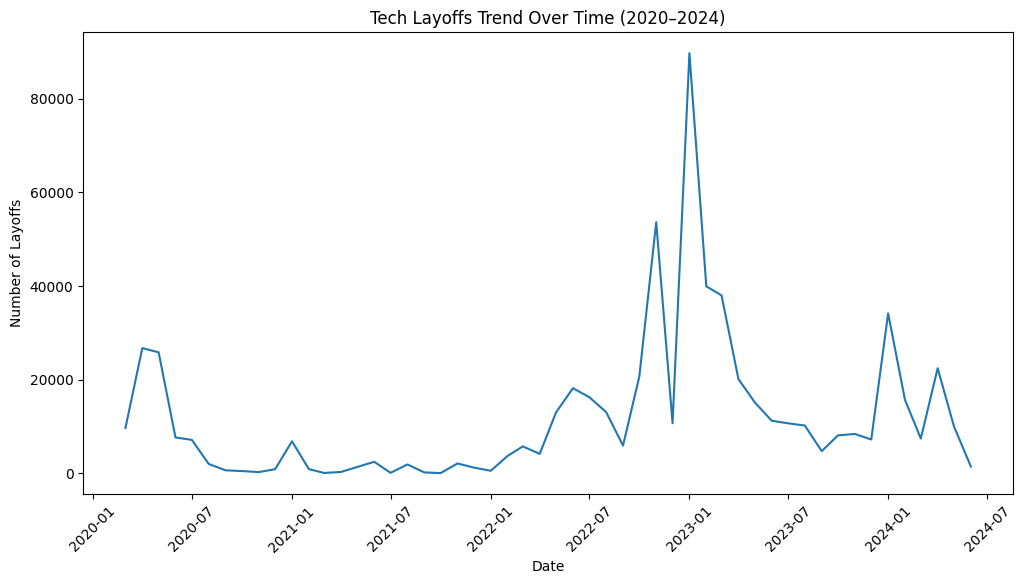

In [17]:
plt.figure(figsize=(12,6))
plt.plot(monthly_layoffs['date'], monthly_layoffs['Laid_Off_Count'])

plt.title("Tech Layoffs Trend Over Time (2020–2024)")
plt.xlabel("Date")
plt.ylabel("Number of Layoffs")
plt.xticks(rotation=45)

plt.show()

In [18]:
peak = monthly_layoffs.loc[monthly_layoffs['Laid_Off_Count'].idxmax()]
peak

year                             2023
month                               1
Laid_Off_Count                89709.0
date              2023-01-01 00:00:00
Name: 33, dtype: object

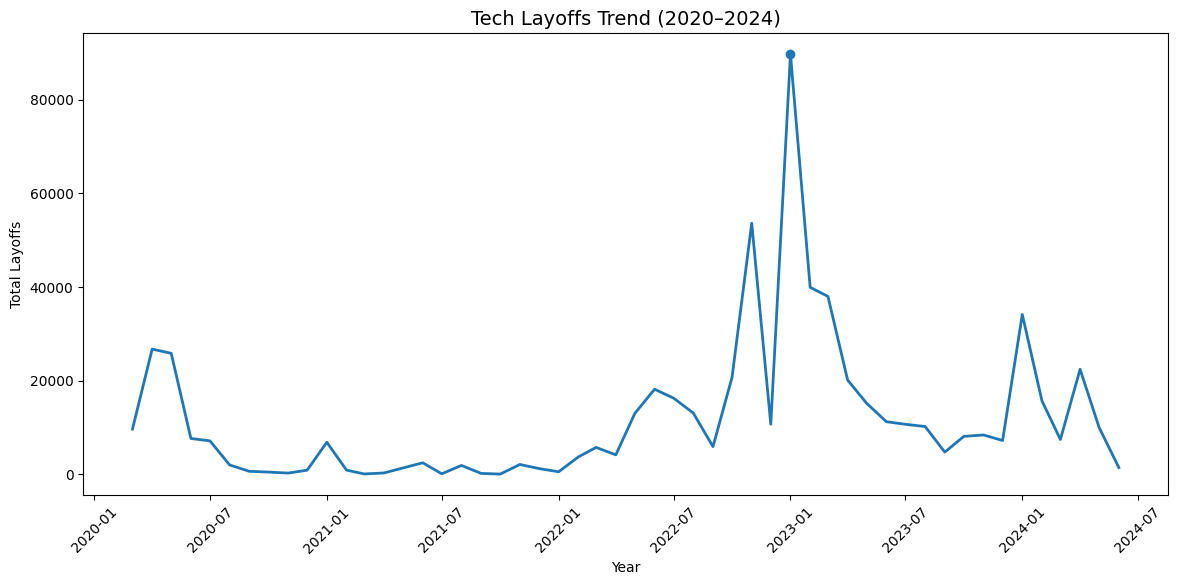

In [19]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_layoffs['date'],
    monthly_layoffs['Laid_Off_Count'],
    linewidth=2
)

plt.scatter(peak['date'], peak['Laid_Off_Count'])

plt.title("Tech Layoffs Trend (2020–2024)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Total Layoffs")
plt.xticks(rotation=45)

plt.show()

In [20]:
# Group by industry
industry_layoffs = (
    df.groupby('Industry')['Laid_Off_Count']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

industry_layoffs.head(10)

,Industry,Laid_Off_Count
0,Retail,70157.0
1,Consumer,67675.0
2,Transportation,59417.0
3,Other,59261.0
4,Food,45625.0
5,Finance,43103.0
6,Hardware,37750.0
7,Healthcare,36907.0
8,Travel,23132.0
9,Real Estate,19108.0


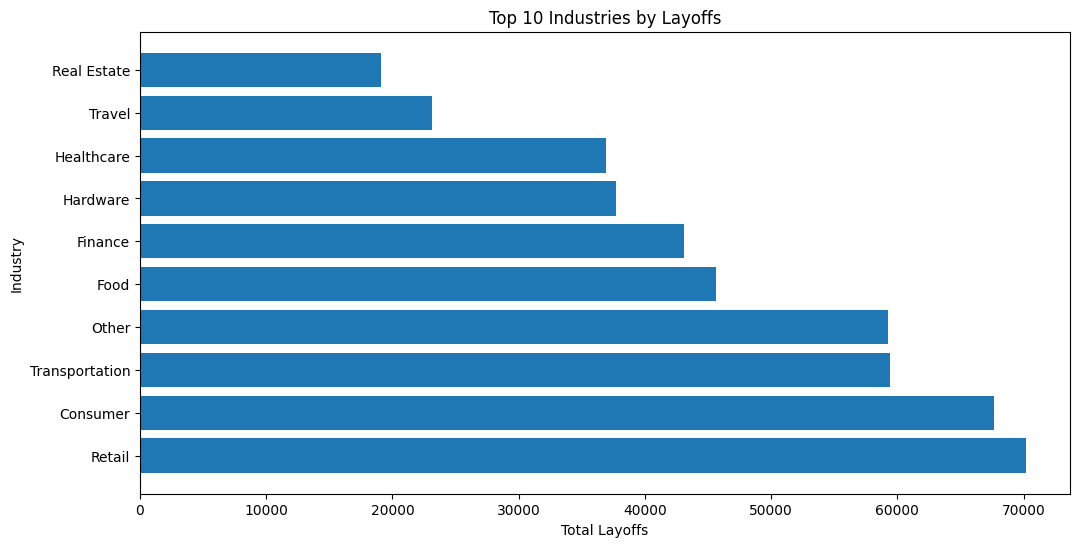

In [21]:
top_industries = industry_layoffs.head(10)

plt.figure(figsize=(12,6))
plt.barh(top_industries['Industry'], top_industries['Laid_Off_Count'])

plt.title("Top 10 Industries by Layoffs")
plt.xlabel("Total Layoffs")
plt.ylabel("Industry")

plt.show()

In [22]:
company_layoffs = (
    df.groupby('Company')['Laid_Off_Count']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

company_layoffs.head(10)

,Company,Laid_Off_Count
0,Amazon,27840.0
1,Meta,21000.0
2,Tesla,14500.0
3,Microsoft,14058.0
4,Google,13472.0
5,Dell,12650.0
6,SAP,11000.0
7,Salesforce,10840.0
8,Philips,10000.0
9,Cisco,8700.0


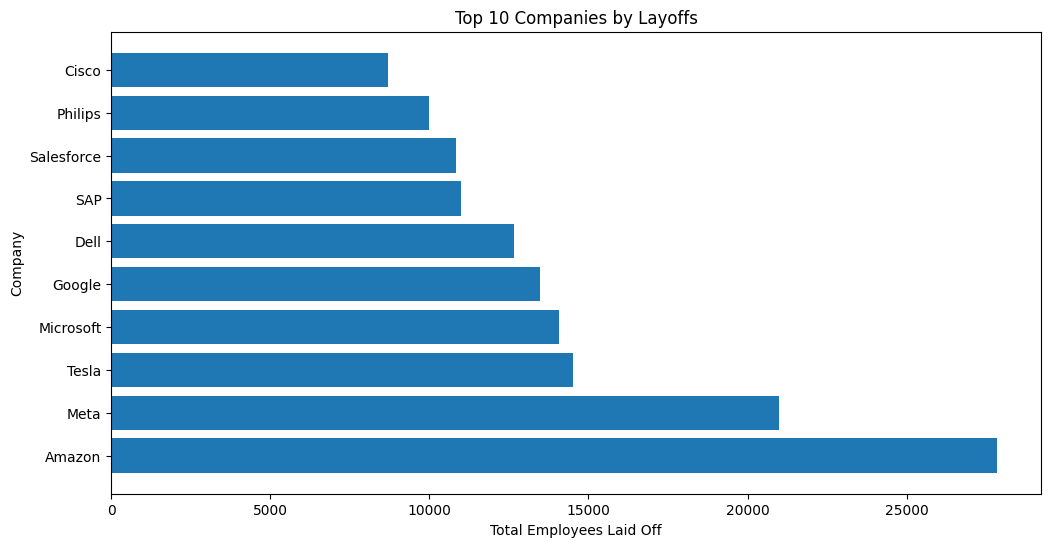

In [23]:
top_companies = company_layoffs.head(10)

plt.figure(figsize=(12,6))
plt.barh(top_companies['Company'], top_companies['Laid_Off_Count'])

plt.title("Top 10 Companies by Layoffs")
plt.xlabel("Total Employees Laid Off")
plt.ylabel("Company")

plt.show()

In [24]:
#remove missing percentage values
df_pct = df.dropna(subset=['Percentage'])

company_pct = (
    df_pct.groupby('Company')['Percentage']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
company_pct.head(10)

,Company,Percentage
0,Zulily,1.0
1,Medsaf,1.0
2,Limelight,1.0
3,Project Ronin,1.0
4,Jump,1.0
5,Kitty Hawk,1.0
6,Openpay,1.0
7,Reali,1.0
8,HOOQ,1.0
9,Protocol,1.0


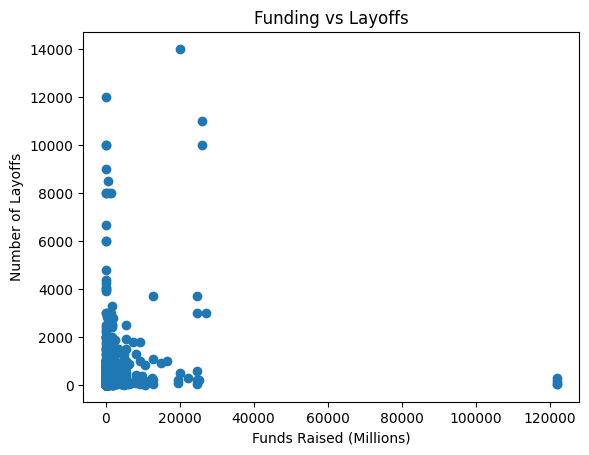

In [25]:
plt.scatter(
    df['Funds_Raised'],
    df['Laid_Off_Count']
)

plt.title("Funding vs Layoffs")
plt.xlabel("Funds Raised (Millions)")
plt.ylabel("Number of Layoffs")


plt.show()

In [26]:
country_layoffs = (
    df.groupby('Country')['Laid_Off_Count']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_layoffs.head(10)

,Country,Laid_Off_Count
0,United States,414013.0
1,India,51234.0
2,Germany,26353.0
3,United Kingdom,19769.0
4,Netherlands,18445.0
5,Sweden,13619.0
6,Brazil,11323.0
7,Canada,10321.0
8,Singapore,7419.0
9,China,7190.0


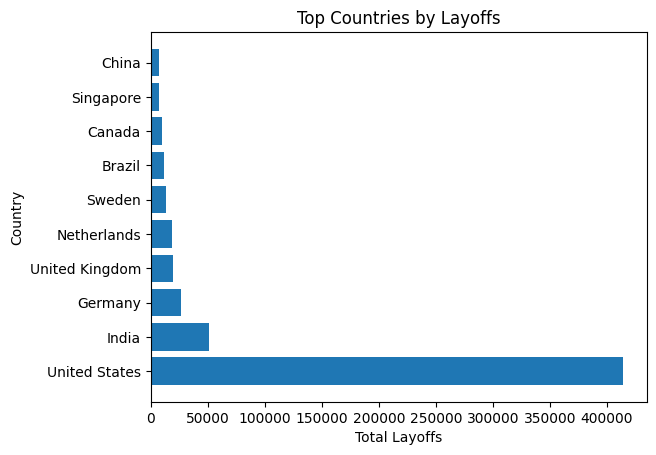

In [27]:
top_countries = country_layoffs.head(10)

plt.barh(top_countries['Country'], top_countries['Laid_Off_Count'])

plt.title("Top Countries by Layoffs")
plt.xlabel("Total Layoffs")
plt.ylabel("Country")

plt.show()

In [28]:
total_layoffs = df['Laid_Off_Count'].sum()

country_layoffs['percentage_share'] = (
    country_layoffs['Laid_Off_Count'] / total_layoffs
) * 100

country_layoffs.head(10)

,Country,Laid_Off_Count,percentage_share
0,United States,414013.0,67.189615
1,India,51234.0,8.314697
2,Germany,26353.0,4.276793
3,United Kingdom,19769.0,3.208285
4,Netherlands,18445.0,2.993414
5,Sweden,13619.0,2.210209
6,Brazil,11323.0,1.837594
7,Canada,10321.0,1.674981
8,Singapore,7419.0,1.204020
9,China,7190.0,1.166855


In [29]:
stage_layoffs = (
    df.groupby('Stage')['Laid_Off_Count']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

stage_layoffs.head(10)

,Stage,Laid_Off_Count
0,Post-IPO,338795.0
1,Unknown,60401.0
2,Acquired,59457.0
3,Series B,29188.0
4,Series D,24705.0
5,Series C,24171.0
6,Series E,22041.0
7,Series F,13513.0
8,Private Equity,10999.0
9,Series A,8055.0


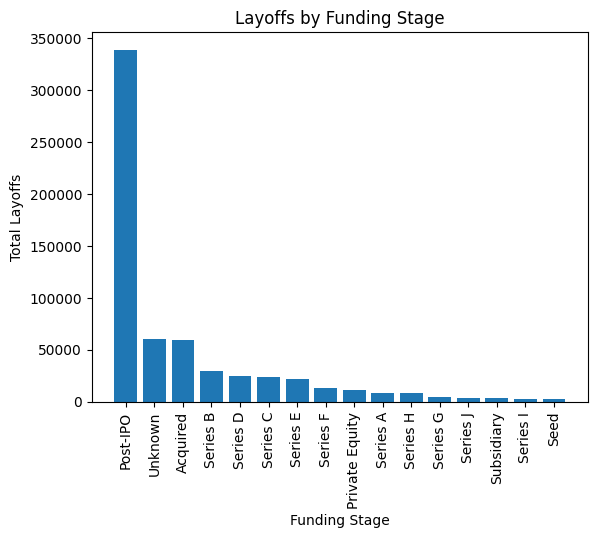

In [30]:
plt.bar(stage_layoffs['Stage'], stage_layoffs['Laid_Off_Count'])

plt.title("Layoffs by Funding Stage")
plt.xlabel("Funding Stage")
plt.ylabel("Total Layoffs")

plt.xticks(rotation=90)
plt.show()

In [31]:
stage_pct = (
    df.groupby('Stage')['Percentage']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

stage_pct.head(10)

,Stage,Percentage
0,Seed,0.573226
1,Series A,0.321959
2,Series B,0.291848
3,Acquired,0.278628
4,Unknown,0.266786
5,Subsidiary,0.236667
6,Series C,0.221793
7,Series D,0.187912
8,Series E,0.164255
9,Series G,0.162000


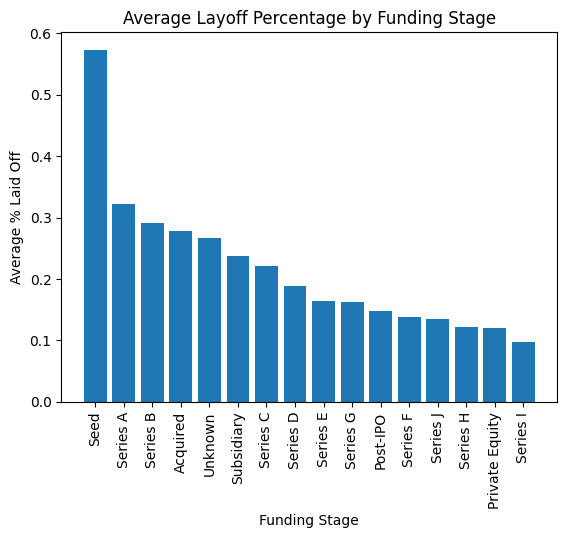

In [32]:
plt.bar(stage_pct['Stage'], stage_pct['Percentage'])

plt.title("Average Layoff Percentage by Funding Stage")
plt.xlabel("Funding Stage")
plt.ylabel("Average % Laid Off")

plt.xticks(rotation=90)
plt.show()

In [33]:
monthly_wave = df.groupby(['year','month'])['Laid_Off_Count'].sum().reset_index()


monthly_wave['date'] = pd.to_datetime(
    monthly_wave[['year','month']].assign(day=1)
)

# Sort
monthly_wave = monthly_wave.sort_values('date')

monthly_wave.head()

,year,month,Laid_Off_Count,date
0,2020,3,9628.0,2020-03-01
1,2020,4,26710.0,2020-04-01
2,2020,5,25804.0,2020-05-01
3,2020,6,7627.0,2020-06-01
4,2020,7,7112.0,2020-07-01


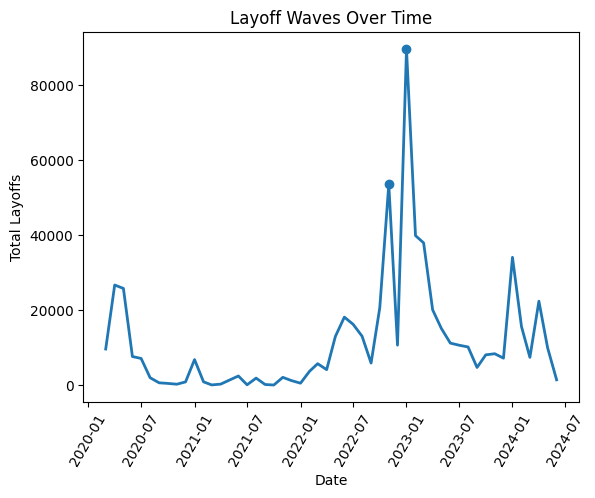

In [36]:
plt.plot(monthly_wave['date'], monthly_wave['Laid_Off_Count'], linewidth=2)
wave_data = monthly_wave[monthly_wave['Laid_Off_Count'] > 50000]

plt.scatter(wave_data['date'], wave_data['Laid_Off_Count'])

plt.title("Layoff Waves Over Time")
plt.xlabel("Date")
plt.ylabel("Total Layoffs")

plt.xticks(rotation=60)
plt.show()

In [37]:
monthly_wave.sort_values(by='Laid_Off_Count', ascending=False).head()

,year,month,Laid_Off_Count,date
33,2023,1,89709.0,2023-01-01
31,2022,11,53594.0,2022-11-01
34,2023,2,39902.0,2023-02-01
35,2023,3,37963.0,2023-03-01
45,2024,1,34107.0,2024-01-01
